In [1]:
import pandas as pd
import numpy as np

data=pd.read_csv("/kaggle/input/datasets/karan12singh123/cancer/Breast_Cancer.csv")

In [2]:
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
col_list=data.columns
for col in col_list:
    print(f"{col} :{data[col].unique()}")
    print("\n")

Age :[68 50 58 47 51 40 69 46 65 48 62 61 56 43 60 57 55 63 66 53 59 54 49 64
 42 37 67 31 52 33 45 38 39 36 41 44 32 34 35 30]


Race :['White' 'Black' 'Other']


Marital Status :['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']


T Stage  :['T1' 'T2' 'T3' 'T4']


N Stage :['N1' 'N2' 'N3']


6th Stage :['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']


differentiate :['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']


Grade :['3' '2' '1' ' anaplastic; Grade IV']


A Stage :['Regional' 'Distant']


Tumor Size :[  4  35  63  18  41  20   8  30 103  32  13  59  15  19  46  24  25  29
  40  70  22  50  17  21  10  27  23   5  51   9  55 120  77   2  11  12
  26  75 130  34  80   3  60  14  16  45  36  76  38  49   7  72 100  43
  62  37  68  52  85  57  39  28  48 110  65   6 105 140  42  31  90 108
  98  47  54  61  74  33   1  87  81  58 117  44 123 133  95 107  92  69
  56  82  66  78  97  88  53  83 101  84 115  73 125 104  94  86  64  96
  79  67]

In [4]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [5]:
data['Race']

0       White
1       White
2       White
3       White
4       White
        ...  
4019    Other
4020    White
4021    White
4022    Black
4023    White
Name: Race, Length: 4024, dtype: object

In [6]:
for col in col_list:
    print(f"{col}: {data[col].nunique()}")

Age: 40
Race: 3
Marital Status: 5
T Stage : 4
N Stage: 3
6th Stage: 5
differentiate: 4
Grade: 4
A Stage: 2
Tumor Size: 110
Estrogen Status: 2
Progesterone Status: 2
Regional Node Examined: 54
Reginol Node Positive: 38
Survival Months: 107
Status: 2


In [7]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
x=data.drop(columns=['Status'])
y=data['Status']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,
                                           random_state=42,
                                          stratify=y
                                          )


In [10]:
scaler_cols=xtrain.select_dtypes(include='int64').columns
ohe_cols=xtrain.select_dtypes(include="object").columns

In [11]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

xtrain_encoded = pd.DataFrame(
    ohe.fit_transform(xtrain[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=xtrain.index
)

xtest_encoded = pd.DataFrame(
    ohe.transform(xtest[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=xtest.index
)

xtrain = xtrain.drop(columns=ohe_cols)
xtest = xtest.drop(columns=ohe_cols)

xtrain = pd.concat([xtrain, xtrain_encoded], axis=1)
xtest = pd.concat([xtest, xtest_encoded], axis=1)
smote = SMOTE(random_state=42)

xtrain, ytrain = smote.fit_resample(xtrain, ytrain)


In [13]:
le=LabelEncoder()
ytrain=le.fit_transform(ytrain)
ytest=le.transform(ytest)

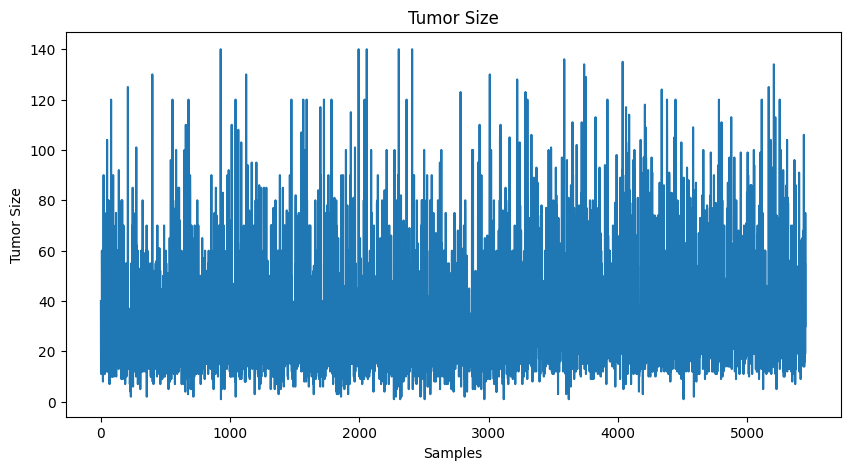

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(xtrain["Tumor Size"])
plt.xlabel("Samples")
plt.ylabel("Tumor Size")
plt.title("Tumor Size")
plt.show()

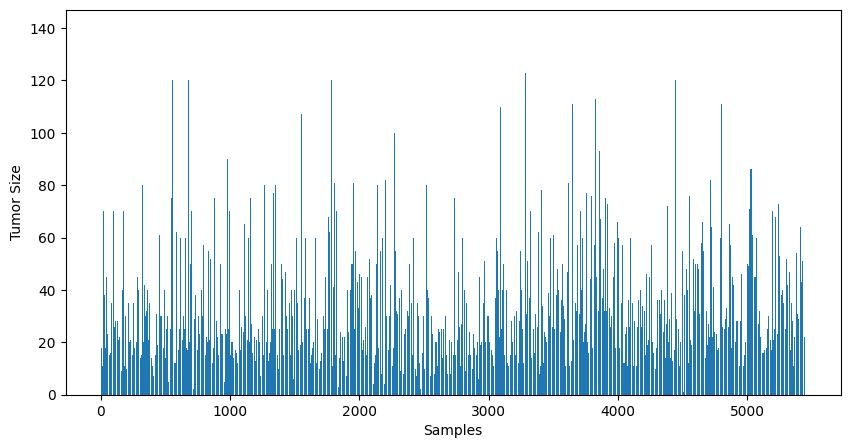

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(xtrain)), xtrain["Tumor Size"])
plt.xlabel("Samples")
plt.ylabel("Tumor Size")
plt.show()

(array([ 122.,  663., 1263.,  977.,  701.,  391.,  265.,  300.,  220.,
         143.,  105.,   96.,   66.,   37.,   45.,   13.,    8.,   23.,
           5.,    9.]),
 array([  1.  ,   7.95,  14.9 ,  21.85,  28.8 ,  35.75,  42.7 ,  49.65,
         56.6 ,  63.55,  70.5 ,  77.45,  84.4 ,  91.35,  98.3 , 105.25,
        112.2 , 119.15, 126.1 , 133.05, 140.  ]),
 <BarContainer object of 20 artists>)

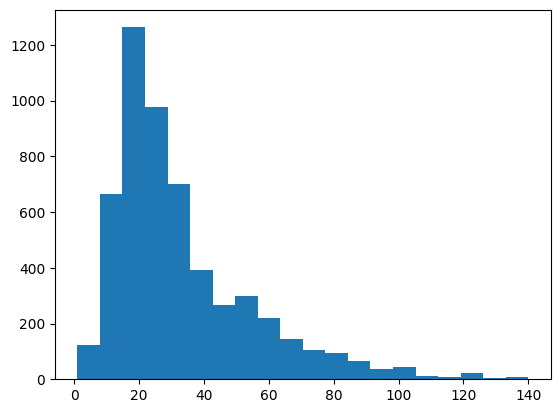

In [16]:
plt.hist(xtrain["Tumor Size"], bins=20)

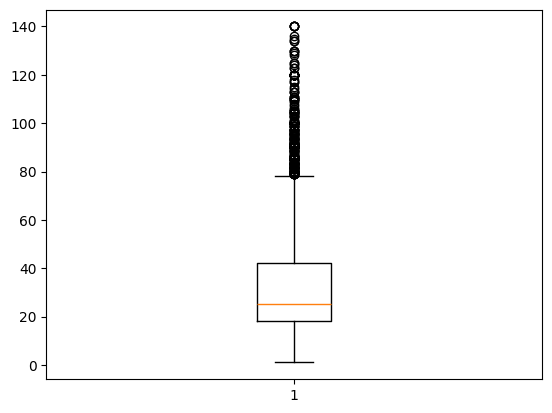

In [17]:


plt.boxplot(xtrain["Tumor Size"])
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
xtrain[scaler_cols]=ss.fit_transform(xtrain[scaler_cols])
xtest[scaler_cols]=ss.transform(xtest[scaler_cols])

In [19]:
import torch
xtrain=torch.tensor(xtrain.values,dtype=torch.float32)
xtest=torch.tensor(xtest.values,dtype=torch.float32)

In [20]:
from torch.utils.data import Dataset,DataLoader

class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features=features
        self.labels=labels
    def __len__(self):
        return self.features.shape[0]
    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [21]:
traindataset=CustomDataset(xtrain,ytrain)
testdataset=CustomDataset(xtest,ytest)

In [22]:
traindataloader=DataLoader(traindataset,
                           batch_size=32,
                           shuffle=True,
                           num_workers=4 ,
                           pin_memory=True
                          )
testdataloader=DataLoader(
    testdataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [23]:
import torch.nn as nn
class MyModel(nn.Module):
    def __init__(self,num_input,num_output,hidden_layers,nuerons,dropout_rate):
        super().__init__()
        layers=[]
        for i in range(hidden_layers):
            layers.append(nn.Linear(num_input,nuerons))
            layers.append(nn.BatchNorm1d(nuerons))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            num_input=nuerons
        layers.append(nn.Linear(num_input,num_output))
        layers.append(nn.Sigmoid())
        self.network=nn.Sequential(*layers)
    def forward(self,features):
        return self.network(features)
        



In [24]:
import torch.optim as optim
def objective(trial):
    input_dim=xtrain.shape[1]
    output_dim=1

    number_of_hidden_layers=trial.suggest_int("number_of_hidden_layers",1,10)
    number_of_neurons=trial.suggest_int("number_of_neurons",8,128,step=8)
    rate_of_dropout=trial.suggest_float("rate_of_dropout",.1,.5,step=.1)
    optimizer_name=trial.suggest_categorical("optimizer",['adam','sgd','rmsprop'])
    no_of_epochs=trial.suggest_int("no_of_epochs",10,25)
    regularization = trial.suggest_float(
    "weight_decay",1e-5,1e-3,log=True)
    learning_rate = trial.suggest_float(
    "lr",
    1e-4,
    1e-2,log=True)
    
    loss_fun=nn.BCELoss()

    model=MyModel(
        input_dim,
        output_dim,
        number_of_hidden_layers,
        number_of_neurons,
        rate_of_dropout)

    device=torch.device('cuda' if torch.cuda.is_available() else "cpu")
    model=model.to(device)


    
    if optimizer_name=='adam':
        optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=regularization)
    elif optimizer_name=='sgd':
        optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=regularization)
    else:
        optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=regularization)




    model.train()
    
    for i in range(no_of_epochs):

        for features,labels in traindataloader:

            features,labels=features.to(device),labels.to(device)
            y_pred=model(features)
            loss=loss_fun(y_pred,labels.unsqueeze(1).float())


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    acc = []

    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for batch_features, batch_labels in testdataloader:

          # move data to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
            outputs = model(batch_features)
            prediction=(outputs>.5).float()
            correct += (prediction == batch_labels.unsqueeze(1).float()).sum().item()
            total += batch_labels.size(0)
    accuracy = correct / total
    return accuracy

In [25]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-07-04 15:14:44,319] A new study created in memory with name: no-name-1ac5e179-d01e-4975-96b5-d5ae9519d4ce
[I 2026-07-04 15:15:10,845] Trial 0 finished with value: 0.8260869565217391 and parameters: {'number_of_hidden_layers': 7, 'number_of_neurons': 120, 'rate_of_dropout': 0.5, 'optimizer': 'adam', 'no_of_epochs': 20, 'weight_decay': 1.412935202236877e-05, 'lr': 0.0076688338700061165}. Best is trial 0 with value: 0.8260869565217391.
[I 2026-07-04 15:15:20,643] Trial 1 finished with value: 0.8583850931677018 and parameters: {'number_of_hidden_layers': 6, 'number_of_neurons': 56, 'rate_of_dropout': 0.30000000000000004, 'optimizer': 'sgd', 'no_of_epochs': 10, 'weight_decay': 1.4062415327759088e-05, 'lr': 0.0010500950034363608}. Best is trial 1 with value: 0.8583850931677018.
[I 2026-07-04 15:15:36,274] Trial 2 finished with value: 0.8484472049689441 and parameters: {'number_of_hidden_layers': 2, 'number_of_neurons': 88, 'rate_of_dropout': 0.30000000000000004, 'optimizer': 'rmsprop

In [26]:
print(study.best_params)
best_params=study.best_params

{'number_of_hidden_layers': 3, 'number_of_neurons': 112, 'rate_of_dropout': 0.4, 'optimizer': 'rmsprop', 'no_of_epochs': 17, 'weight_decay': 6.501479917263574e-05, 'lr': 0.009761109805744012}


In [27]:
#new model with best perameters 
model=MyModel(
    num_input=xtrain.shape[1],
    num_output=1,
    hidden_layers=best_params['number_of_hidden_layers'],
    nuerons=best_params['number_of_neurons'],
    dropout_rate=best_params['rate_of_dropout'],
    
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

loss_fun=nn.BCELoss()

epochs=best_params['no_of_epochs']

if best_params['optimizer']=='adam':
    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    )
elif best_params['optimizer']=='SGD':
    optimizer=torch.optim.SGD(
        model.parameters(),
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    )
else :
    optimizer=torch.optim.RMSprop(
        model.parameters(),
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    )



In [28]:
model.train()

for i in range(epochs):
    running_loss=0.0
    for features,labels in traindataloader:
        features,labels=features.to(device),labels.to(device)
        y_pred=model(features)
        loss=loss_fun(y_pred,labels.unsqueeze(1).float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_loss=running_loss/len(traindataloader)
    print(f"epochs:{i} and loss :{epoch_loss}")
        

epochs:0 and loss :0.49323373022135236
epochs:1 and loss :0.43633099301168093
epochs:2 and loss :0.42984556977511845
epochs:3 and loss :0.4180137547310333
epochs:4 and loss :0.3976346602042516
epochs:5 and loss :0.39390487742354297
epochs:6 and loss :0.3896448986049284
epochs:7 and loss :0.3824612472140998
epochs:8 and loss :0.38231157698826485
epochs:9 and loss :0.3684867185633085
epochs:10 and loss :0.36763709016710694
epochs:11 and loss :0.3733207613055469
epochs:12 and loss :0.35964521878992606
epochs:13 and loss :0.36218116741779954
epochs:14 and loss :0.3623736798763275
epochs:15 and loss :0.35514116884149305
epochs:16 and loss :0.352001296497925


In [49]:
#evaluation of model 
model.eval()
total=0
correct=0
with torch.no_grad():
    
    for features ,labels in testdataloader:
        
        features,labels=features.to(device),labels.to(device)
        y_pred=model(features)
        prediction=(y_pred>.811).float()
        correct+=(prediction==labels.unsqueeze(1).float()).sum().item()
        total+=labels.size(0)
        
accuracy=correct/total
print(accuracy)
    

0.8906832298136645


In [52]:
from sklearn.metrics import classification_report
import torch

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for features, labels in testdataloader:
        features = features.to(device)

        outputs = model(features)

        # If using BCEWithLogitsLoss:
        # outputs = torch.sigmoid(outputs)

        predictions = (outputs >= 0.81).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy().flatten())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       682
           1       0.80      0.38      0.52       123

    accuracy                           0.89       805
   macro avg       0.85      0.68      0.73       805
weighted avg       0.88      0.89      0.87       805



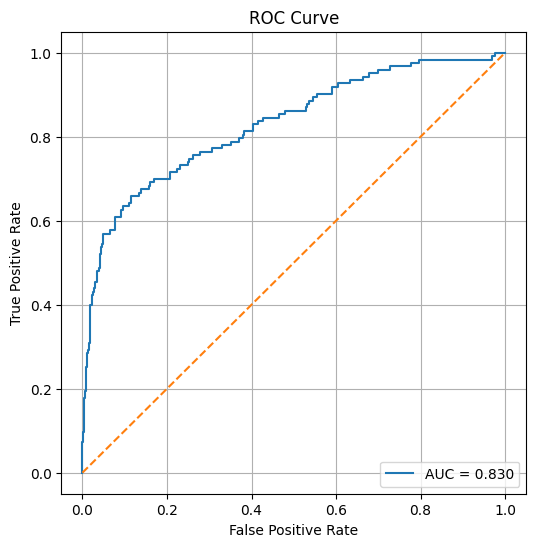

AUC Score: 0.8297093674749064


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import torch

model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for features, labels in testdataloader:
        features = features.to(device)

        outputs = model(features)      # Shape: (batch_size, 1)

        y_prob.extend(outputs.cpu().numpy().flatten())
        y_true.extend(labels.numpy())

# Calculate AUC
auc = roc_auc_score(y_true, y_prob)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC Score:", auc)
